In [14]:
using DrWatson
@quickactivate "project"
using Agents
using DataFrames
using Plots

In [15]:
include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

In [16]:
using CairoMakie

In [17]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.black, count)
 (Main.white, count)

In [18]:
model = daisyworld(solar_luminosity = 1.0, scenario = :ramp)

StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario

In [19]:
temperature(model) = StatsBase.mean(model.temperature)
mdata = [temperature, :solar_luminosity]

2-element Vector{Any}:
 temperature (generic function with 1 method)
 :solar_luminosity

In [20]:
agent_df, model_df = run!(model, 1000; adata = adata, mdata = mdata)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          396          166
    3 │     2          546          211
    4 │     3          583          272
    5 │     4          587          300
    6 │     5          581          316
    7 │     6          578          319
    8 │     7          573          324
    9 │     8          570          329
   10 │     9          566          332
   11 │    10          566          332
  ⋮   │   ⋮         ⋮            ⋮
  992 │   991            0          900
  993 │   992            0          900
  994 │   993            0          900
  995 │   994            0          896
  996 │   995            0          889
  997 │   996            0          890
  998 │   997            0          892
  999 │   998            0          894
 1000 │   999            0          897
 1001 │  1000           

In [21]:
figure = CairoMakie.Figure(size = (600, 600));
ax1 = figure[1, 1] = Axis(figure, ylabel = "daisy count")
blackl = lines!(ax1, agent_df[!, :time], agent_df[!, :count_black], color = :red)
whitel = lines!(ax1, agent_df[!, :time], agent_df[!, :count_white], color = :blue)
figure[1, 2] = Legend(figure, [blackl, whitel], ["black", "white"])

Legend()

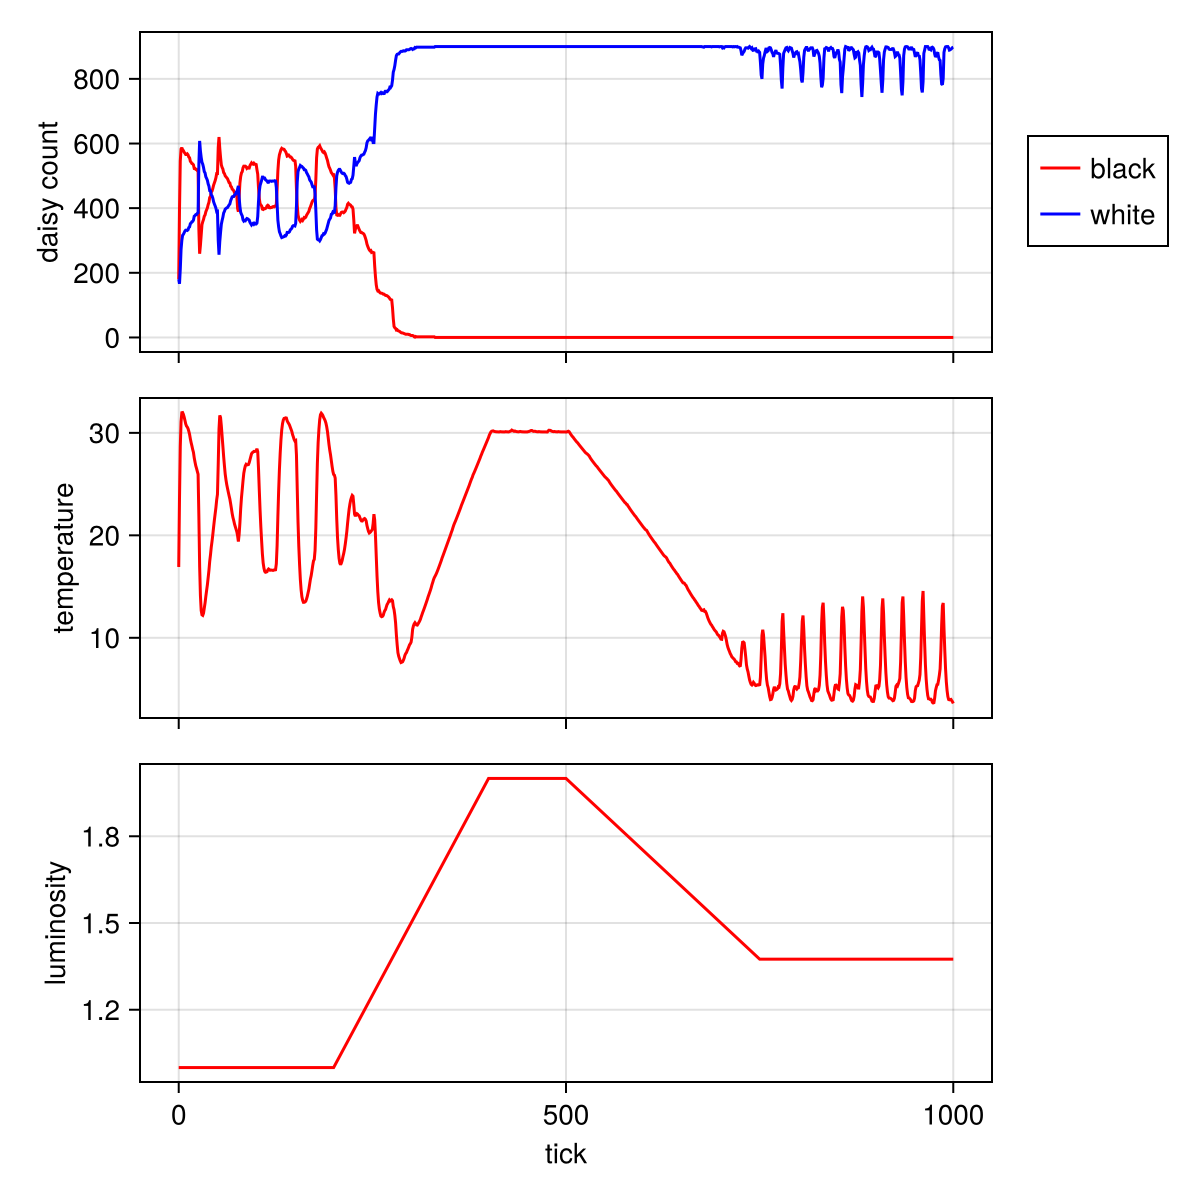

In [22]:
ax2 = figure[2, 1] = Axis(figure, ylabel = "temperature")
ax3 = figure[3, 1] = Axis(figure, xlabel = "tick", ylabel = "luminosity")
lines!(ax2, model_df[!, :time], model_df[!, :temperature], color = :red)
lines!(ax3, model_df[!, :time], model_df[!, :solar_luminosity], color = :red)
for ax in (ax1, ax2); ax.xticklabelsvisible = false; end
figure

In [23]:
save(plotsdir("daisy_luminosity.png"), figure)